# Viewer for raw simulation result files

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import train_utils, glob, torch, pickle, utils, model, copy, os
import response_utils as r_utils
from tqdm import trange


name = '6L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
source_dir = os.getcwd() + '/Raw_results/' + name + '/'

file = os.listdir(source_dir)[195]
data = pickle.load(open(source_dir + file, 'rb'))

# create a Model object for loading weight changes; create a Stimuli object for testing
net = model.Model(data['args'])
stim = train_utils.GaborStimuli(data['args'], simple_mode=False, verbose=False)
xp = stim.x0 + stim.x1
xm = stim.x0 - stim.x1

# number of time points to sample
n_sample = 50
stride = int(len(data['loss']) / n_sample)

fi_curves = np.zeros((net.n_layers, n_sample))
grad_norms = np.zeros((net.n_layers, n_sample))
a_grad_norms = np.zeros(n_sample)
sampled_loss = np.zeros(n_sample)
signal_norms = np.zeros((net.n_layers, n_sample))
delw_norms = np.zeros((net.n_layers, n_sample))

for i in trange(n_sample):
    delw = data['delW'][stride * i]
    sampled_loss[i] = data['loss'][stride * i]
    
    # load weight changes
    net.RESET_WEIGHTS()
    for j in range(net.n_layers):
        net.Ws[j] += utils.recover_matrix(delw['layer_' + str(j)])
        delw_norms[j, i] = np.linalg.norm(delw['layer_' + str(j)]['s'])
    
    # calculate linear FI for trained stimuli at every layer
    for j in range(net.n_layers):
        fi_curves[j, i] = r_utils.get_mean_field_fi(net, stim, to_layer=j+1)
        signal_norms[j, i] = np.linalg.norm(net.get_obs(xp, to_layer=j+1).data.numpy() - net.get_obs(xm, to_layer=j+1).data.numpy())
    
    # calculate gradient norms
    net.RO.weight.data = torch.from_numpy(data['a'][stride * i]).float().t()
    train_utils.zero_and_grad(net, stim, 'MSE', v_teacher=stim.x1 * 10)
    a_grad_norms[i] = np.linalg.norm(net.RO.weight.grad.data.numpy())
    for j in range(net.n_layers):
        grad_norms[j, i] = np.linalg.norm(net.Ls[j].weight.grad.data.numpy())
        

100%|██████████| 50/50 [00:26<00:00,  1.89it/s]


## Plots

### Norm of gradients

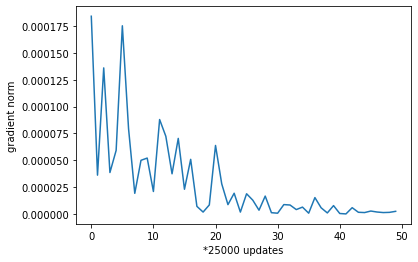

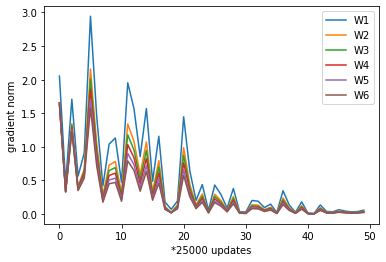

In [51]:
stride_in_steps = data['args'].test_interval * stride
plt.figure()
plt.plot(a_grad_norms)
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('gradient norm')

plt.figure()
for i in range(net.n_layers):
    plt.plot(grad_norms[i], label='W'+str(i+1))
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('gradient norm')
plt.legend()

### Fisher information at every layer

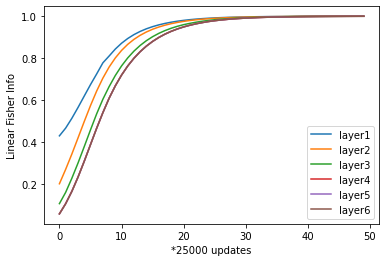

In [57]:
plt.figure()
for i in range(net.n_layers):
    plt.plot(fi_curves[i], label='layer'+str(i+1))
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('Linear Fisher Info')
plt.legend()

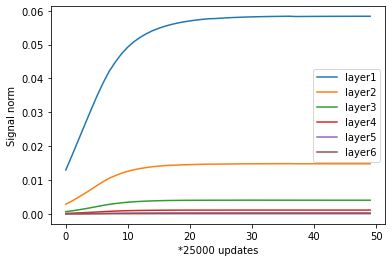

In [58]:
plt.figure()
for i in range(net.n_layers):
    plt.plot(signal_norms[i], label='layer'+str(i+1))
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('Signal norm')
plt.legend()

In [30]:
for i in range(len(os.listdir(source_dir))):
    try:
        file = os.listdir(source_dir)[i]
        raw_data = pickle.load(open(source_dir + file, 'rb'))
        print(i, raw_data['args'].eta)
    except:
        continue

0 1.4536359458361403e-06
1 4.542612543900759e-07
4 1.453636014048243e-05
5 4.542612259683665e-06
10 1.453635860571012e-07
18 4.5426123307379385e-08
19 4.542612441582605e-05
23 1.453635860571012e-07
30 4.542612441582605e-05
31 4.5426123307379385e-08
34 4.5426123307379385e-08
35 4.542612543900759e-07
36 1.4536359458361403e-06
37 4.542612259683665e-06
38 1.453636014048243e-05
45 1.453635860571012e-07
54 1.453635860571012e-07
58 4.542612441582605e-05
59 4.5426123307379385e-08
60 1.453636014048243e-05
61 1.453636014048243e-05
62 4.542612259683665e-06
65 1.4536359458361403e-06
66 4.542612543900759e-07
71 4.542612441582605e-05
72 4.5426123307379385e-08
75 4.542612259683665e-06
76 1.453636014048243e-05
78 4.542612543900759e-07
80 1.4536359458361403e-06
83 4.5426123307379385e-08
84 4.542612441582605e-05
96 1.453635860571012e-07
97 4.542612441582605e-05
99 1.453635860571012e-07
103 4.5426123307379385e-08
104 4.542612441582605e-05
109 4.542612543900759e-07
110 1.4536359458361403e-06
120 1.4536360

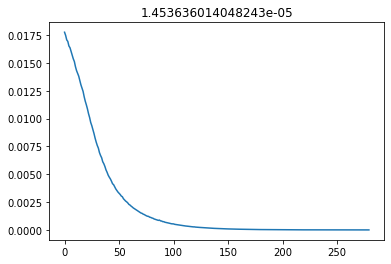

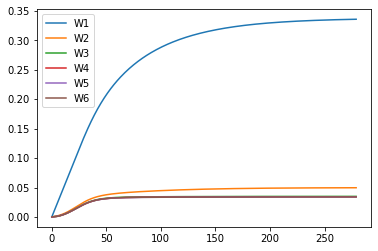

In [89]:

file = os.listdir(source_dir)[195]

raw_data = pickle.load(open(source_dir + file, 'rb'))
plt.figure()
plt.plot(raw_data['loss'])
plt.title(raw_data['args'].eta)

# compute norms of delW matrices
delw_norms = []
for i in range(raw_data['args'].n_layers):
    delw_norms.append([np.linalg.norm(d['layer_' + str(i)]['s']) for d in raw_data['delW']])

plt.figure()
for i in range(raw_data['args'].n_layers):
    plt.plot(delw_norms[i], label='W' + str(i+1))
plt.legend()


## Load multiple raw data files

Text(0.5, 1.0, '4L_MSE_GD_eta_sigs0p2_sigw0p8_reps')

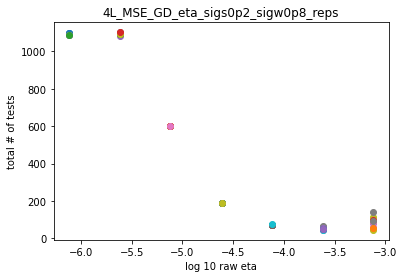

In [45]:
name = '4L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
source_dir = os.getcwd() + '/Raw_results/' + name + '/'

plt.figure()
for i in range(len(os.listdir(source_dir))):
    try:
        file = os.listdir(source_dir)[i]
        raw_data = pickle.load(open(source_dir + file, 'rb'))
        plt.scatter(np.log10(raw_data['args'].eta), len(raw_data['loss']))
    except:
        continue
plt.xlabel('log 10 raw eta')
plt.ylabel('total # of tests')
plt.title(name)

In [46]:
len(raw_data['loss'])

74

Text(0.5, 1.0, '6L_MSE_GD_eta_sigs0p2_sigw0p8_reps')

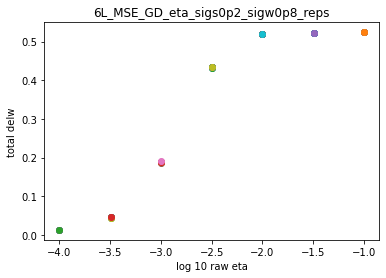

In [42]:
plt.figure()
for i in range(len(os.listdir(source_dir))):
    try:
        file = os.listdir(source_dir)[i]
        raw_data = pickle.load(open(source_dir + file, 'rb'))
        delw = raw_data['delW'][-1]
        tot_delw_norm = 0
        for k in delw.keys():
            tot_delw_norm += np.linalg.norm(delw[k]['s'])
        plt.scatter(np.log10(raw_data['args'].eta * np.linalg.norm(raw_data['a'][-1])), tot_delw_norm)
    except:
        continue

plt.xlabel('log 10 raw eta')
plt.ylabel('total delw')
plt.title(name)

## Gradient at checkpoints

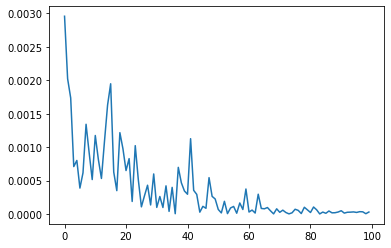

In [122]:
plt.figure()
plt.plot(a_grad_norms)

Text(0.5, 0, 'time')

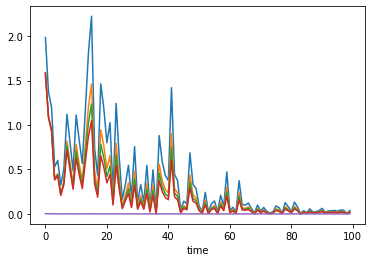

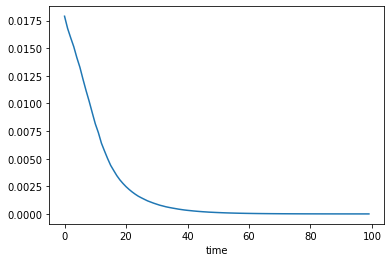

In [121]:
plt.figure()
plt.plot(grad_norms.T)
plt.plot(a_grad_norms)
plt.xlabel('time')
plt.figure()
plt.plot(sampled_loss)
plt.xlabel('time')